# Approach 11: McSharry autoencoder

Replaces the Aliev-Panfilov PDE approach (approach 10) with the McSharry phenomenological ODE for ECG morphology. The 12-lead ECG is treated as the output of a dynamical system on a limit cycle, with P/Q/R/S/T waves as Gaussian attractors.

A 1D adaptive residual encoder maps the 12-channel ECG to 83 McSharry parameters (rate $f$, baseline $z_0$, amplitudes $a_i$, widths $b_i$, phases $\theta_i$ for the five waves). Reconstruction loss is MSE between the analytical McSharry signal and the empirical median beat. The MLP classifier sees only those physical parameters.

Requires `preprocessed_cache_brazil.h5` from `chagas_resnet_classifier.ipynb`.

In [4]:
import math
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings("ignore")
import logging
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
)
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

sns.set_context("notebook")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S")
logger = logging.getLogger("mcsharry_pinn")

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [5]:
CFG = {
    "preprocessed_cache": "preprocessed_cache_brazil.h5",
    "val_fraction": 0.15,
    "test_fraction": 0.15,
    "random_seed": 42,
    "target_fs": 500,
    "target_duration_s": 10,
    "in_channels": 12,
    "base_ch": 64,
    "num_adap_blocks": 4,
    "kernel_size": 15,
    "dropout": 0.2,
    "lambda_ode": 1.0,
    "epochs": 40,
    "batch_size": 16,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "warmup_epochs": 2,
    "grad_clip": 1.0,
    "num_workers": 4,
    "focal_alpha": 0.25,
    "focal_gamma": 2.0,
}

seq_len = CFG["target_fs"] * CFG["target_duration_s"]
dt = 1.0 / CFG["target_fs"]
print(f"seq_len={seq_len}, dt={dt}")

seq_len=5000, dt=0.002


In [6]:
cache_file = CFG["preprocessed_cache"]
assert Path(cache_file).exists(), f"Missing {cache_file} — run chagas_resnet_classifier.ipynb first."

from sklearn.model_selection import GroupShuffleSplit
import os

with h5py.File(cache_file, "r") as f:
    n_total = f["labels"].shape[0]
    all_labels = f["labels"][:]
    all_exam_ids = f["exam_ids"][:] if "exam_ids" in f else np.arange(n_total)
    print(f"Samples: {n_total:,} | Chagas+ {100*all_labels.mean():.1f}%")

code15_dir = "4916206"
samitrop_dir = "sami-trop"

df_code15 = pd.read_csv(os.path.join(code15_dir, "exams.csv")) if os.path.exists(os.path.join(code15_dir, "exams.csv")) else pd.DataFrame()
df_samitrop = pd.read_csv(os.path.join(samitrop_dir, "exams.csv")) if os.path.exists(os.path.join(samitrop_dir, "exams.csv")) else pd.DataFrame()

if not df_code15.empty:
    df_code15["source"] = "code15"
if not df_samitrop.empty:
    df_samitrop["source"] = "samitrop"

df_meta = pd.concat([df_code15, df_samitrop], ignore_index=True)

if not df_meta.empty and "exam_id" in df_meta.columns and "patient_id" in df_meta.columns:
    exam_to_patient = dict(zip(df_meta["exam_id"], df_meta["patient_id"]))
    exam_to_source = dict(zip(df_meta["exam_id"], df_meta["source"]))

    patient_ids = np.array([exam_to_patient.get(eid, eid) for eid in all_exam_ids])
    sources = np.array([exam_to_source.get(eid, "unknown") for eid in all_exam_ids])

    samitrop_mask = (sources == "samitrop")
    samitrop_indices = np.where(samitrop_mask)[0]

    code15_indices = np.where(~samitrop_mask)[0]
    code15_patient_ids = patient_ids[code15_indices]

    gss_test = GroupShuffleSplit(
        n_splits=1, test_size=CFG["test_fraction"], random_state=CFG["random_seed"]
    )
    trainval_idx_rel, test_idx_rel = next(
        gss_test.split(code15_indices, groups=code15_patient_ids)
    )
    code15_trainval_indices = code15_indices[trainval_idx_rel]
    test_indices = code15_indices[test_idx_rel]

    trainval_patient_ids = patient_ids[code15_trainval_indices]
    gss_val = GroupShuffleSplit(
        n_splits=1,
        test_size=CFG["val_fraction"] / (1.0 - CFG["test_fraction"]),
        random_state=CFG["random_seed"],
    )
    train_idx_rel, val_idx_rel = next(
        gss_val.split(code15_trainval_indices, groups=trainval_patient_ids)
    )
    train_indices = code15_trainval_indices[train_idx_rel]
    val_indices = code15_trainval_indices[val_idx_rel]

else:
    print("Warning: Could not load patient metadata. Falling back to random split.")
    samitrop_indices = np.array([], dtype=int)
    n_code15 = n_total
    n_test = int(n_code15 * CFG["test_fraction"])
    n_val = int(n_code15 * CFG["val_fraction"])
    n_train = n_code15 - n_val - n_test
    rng = np.random.RandomState(CFG["random_seed"])
    perm = rng.permutation(n_code15)
    train_indices = perm[:n_train]
    val_indices = perm[n_train : n_train + n_val]
    test_indices = perm[n_train + n_val :]

print(f" Dataset split (CODE-15% 3-way + SaMi-Trop OOD):")
print(f"  Train:    {len(train_indices):>6,} samples | Chagas+ {100*all_labels[train_indices].mean():.1f}%")
print(f"  Val:      {len(val_indices):>6,} samples | Chagas+ {100*all_labels[val_indices].mean():.1f}%")
print(f"  Test:     {len(test_indices):>6,} samples | Chagas+ {100*all_labels[test_indices].mean():.1f}%  (CODE-15% held-out)")
print(f"  SaMi-Trop:{len(samitrop_indices):>6,} samples | Chagas+ {100*all_labels[samitrop_indices].mean():.1f}%  (OOD only)")

from mcsharry_dataset import CachedChagasDataset, extract_median_beat_and_hr

pin = device.type == "cuda"
train_loader = DataLoader(CachedChagasDataset(cache_file, train_indices, dt), batch_size=CFG["batch_size"], shuffle=True, num_workers=CFG["num_workers"], pin_memory=pin, drop_last=True)
val_loader = DataLoader(CachedChagasDataset(cache_file, val_indices, dt), batch_size=CFG["batch_size"], shuffle=False, num_workers=CFG["num_workers"], pin_memory=pin)
test_loader = DataLoader(CachedChagasDataset(cache_file, test_indices, dt), batch_size=CFG["batch_size"], shuffle=False, num_workers=CFG["num_workers"], pin_memory=pin)
samitrop_loader = DataLoader(CachedChagasDataset(cache_file, samitrop_indices, dt), batch_size=CFG["batch_size"], shuffle=False, num_workers=CFG["num_workers"], pin_memory=pin)

Samples: 49,152 | Chagas+ 16.7%
 Dataset split (CODE-15% 3-way + SaMi-Trop OOD):
  Train:    33,244 samples | Chagas+ 13.8%
  Val:       7,143 samples | Chagas+ 14.1%
  Test:      7,134 samples | Chagas+ 13.5%  (CODE-15% held-out)
  SaMi-Trop: 1,631 samples | Chagas+ 100.0%  (OOD only)


In [7]:
@dataclass
class EvalResult:
    auroc: float
    auprc: float
    challenge_score: float
    f1: float
    sens: float
    spec: float

def calculate_tpr_at_capacity(y_true, y_prob, capacity_ratio=0.05):
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    n_positives = np.sum(y_true)
    if n_positives == 0: return 0.0
    M = int(np.floor(len(y_true) * capacity_ratio))
    if M == 0: return 0.0
    sorted_indices = np.argsort(y_prob)[::-1]
    top_m_indices = sorted_indices[:M]
    tp_in_top_m = np.sum(y_true[top_m_indices])
    threshold_prob = y_prob[sorted_indices[M-1]]
    patients_at_threshold = np.where(y_prob == threshold_prob)[0]
    included_at_threshold = np.sum(y_prob[top_m_indices] == threshold_prob)
    if len(patients_at_threshold) > included_at_threshold and included_at_threshold > 0:
        tp_above_threshold = np.sum(y_true[y_prob > threshold_prob])
        positives_at_threshold = np.sum(y_true[patients_at_threshold])
        expected_tp_from_ties = positives_at_threshold * (included_at_threshold / len(patients_at_threshold))
        expected_tp = tp_above_threshold + expected_tp_from_ties
        tpr = expected_tp / n_positives
    else:
        tpr = tp_in_top_m / n_positives
    return float(tpr)

def compute_metrics(y_true, y_prob, thr=0.5):
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    if len(np.unique(y_true)) < 2:
        return EvalResult(float("nan"), float("nan"), float("nan"), 0.0, 0.0, 0.0)
    auroc = roc_auc_score(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)
    cs = calculate_tpr_at_capacity(y_true, y_prob, 0.05)
    yp = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, yp, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    f1 = f1_score(y_true, yp, zero_division=0)
    return EvalResult(auroc, auprc, cs, f1, sens, spec)

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        targets = targets.float()
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        pt = torch.exp(-bce)
        at = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        return (at * (1 - pt).pow(self.gamma) * bce).mean()

In [8]:
class AdapResBlock1D(nn.Module):
    def __init__(self, ch, kernel_size=15, dropout=0.2):
        super().__init__()
        pad = kernel_size // 2
        self.conv = nn.Sequential(
            nn.Conv1d(ch, ch, kernel_size, padding=pad, bias=False),
            nn.GroupNorm(8, ch),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(ch, ch, kernel_size, padding=pad, bias=False),
            nn.GroupNorm(8, ch),
        )
        self.alpha = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        return x + self.alpha * self.conv(x)

class McSharryAutoencoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        c = cfg["base_ch"]
        self.stem = nn.Sequential(
            nn.Conv1d(cfg["in_channels"], c, kernel_size=cfg["kernel_size"], padding=cfg["kernel_size"] // 2, bias=False),
            nn.GroupNorm(8, c),
            nn.GELU(),
        )
        self.blocks = nn.ModuleList([AdapResBlock1D(c, cfg["kernel_size"], cfg["dropout"]) for _ in range(cfg["num_adap_blocks"])])
        self.down = nn.Conv1d(c, c, kernel_size=4, stride=2, padding=1, bias=False)
        self.proj = nn.Sequential(nn.GroupNorm(8, c), nn.GELU())
        
        self.ode_head = nn.Linear(c, 82)
        
        self.clf = nn.Sequential(
            nn.Linear(83, 32),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
        )

    def forward(self, x, hr_f, return_params=False):
        h = self.stem(x)
        for blk in self.blocks:
            h = blk(h)
        h = self.down(h)
        h = self.proj(h)
        ctx = h.mean(dim=-1)
        
        raw = self.ode_head(ctx)
        
        b = F.softplus(raw[:, 0:5]) * 0.5 + 0.01
        
        theta_R = torch.zeros_like(raw[:, 7:8])
        delta_QR = F.softplus(raw[:, 6:7]) * 0.5
        delta_PQ = F.softplus(raw[:, 5:6]) * 0.5
        delta_RS = F.softplus(raw[:, 8:9]) * 0.5
        delta_ST = F.softplus(raw[:, 9:10]) * 0.5
        
        theta_Q = theta_R - delta_QR
        theta_P = theta_Q - delta_PQ
        theta_S = theta_R + delta_RS
        theta_T = theta_S + delta_ST
        
        theta_all = torch.cat([theta_P, theta_Q, theta_R, theta_S, theta_T], dim=-1)
        theta = torch.atan2(torch.sin(theta_all), torch.cos(theta_all))
        
        a = torch.tanh(raw[:, 10:70]) * 5.0
        a = a.view(-1, 12, 5)
        
        z0 = torch.tanh(raw[:, 70:82]) * 0.5
        
        params = {
            'b': b,
            'theta': theta,
            'a': a,
            'z0': z0
        }
        
        flat_params = torch.cat([b, theta, a.view(-1, 60), z0], dim=-1)
        
        clf_in = torch.cat([flat_params, hr_f.unsqueeze(-1)], dim=-1)
        logits = self.clf(clf_in).squeeze(-1)
        
        if return_params:
            return logits, params
        return logits

def mcsharry_pattern_loss(median_beats, params, hr_f, dt):
    """
    MSE loss between analytical McSharry 12-lead beat and empirical median beat.
    median_beats: (B, 12, T_beat)
    """
    B, C, T_beat = median_beats.shape
    
    b = params['b']
    theta_i = params['theta']
    a = params['a']
    z0 = params['z0']
    
    t = torch.arange(0, T_beat, device=median_beats.device).float() * dt
    t = t - (T_beat * dt / 2.0)
    t = t.unsqueeze(0)
    
    theta_t = 2 * math.pi * hr_f.unsqueeze(-1) * t
    
    z_pred = torch.zeros_like(median_beats)
    
    for i in range(5):
        dtheta = theta_t - theta_i[:, i:i+1]
        dtheta = torch.atan2(torch.sin(dtheta), torch.cos(dtheta))
        
        gauss = torch.exp(- (dtheta**2) / (2 * b[:, i:i+1]**2))
        
        z_pred += a[:, :, i:i+1] * gauss.unsqueeze(1)
        
    z_pred += z0.unsqueeze(-1)
    
    residual = z_pred - median_beats
    return residual.pow(2).mean()

In [9]:
import os

CKPT = "approach11_mcsharry_code15_best.pt"

model = McSharryAutoencoder(CFG).to(device)

if os.path.exists(CKPT):
    model.load_state_dict(torch.load(CKPT, map_location=device))
    print(f"Loaded checkpoint from {CKPT}, skipping training.")
    best_auroc = float("nan")
else:
    opt = AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
    criterion = FocalLoss(alpha=CFG["focal_alpha"], gamma=CFG["focal_gamma"])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CFG["epochs"])
    best_auroc = 0.0
    best_state = None

    for epoch in range(CFG["epochs"]):
        model.train()
        tot = tot_cls = tot_recon = 0.0
        n = 0
        pbar = tqdm(train_loader, desc=f"epoch {epoch+1}/{CFG['epochs']}")
        for x, y, median_beats, hr_f in pbar:
            x, y = x.to(device), y.to(device).float()
            median_beats, hr_f = median_beats.to(device), hr_f.to(device)
            opt.zero_grad()
            
            logits, params = model(median_beats, hr_f, return_params=True)
            
            L_cls = criterion(logits, y)
            L_recon = mcsharry_pattern_loss(median_beats, params, hr_f, dt)
            loss = L_cls + CFG["lambda_ode"] * L_recon
            
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])
            opt.step()
            
            bs = x.size(0)
            tot += loss.item() * bs
            tot_cls += L_cls.item() * bs
            tot_recon += L_recon.item() * bs
            n += bs
            pbar.set_postfix(loss=f"{tot/n:.4f}", cls=f"{tot_cls/n:.4f}", recon=f"{tot_recon/n:.4f}")
        sched.step()

        model.eval()
        vy, vp = [], []
        with torch.no_grad():
            for x, y, median_beats, hr_f in val_loader:
                median_beats, hr_f = median_beats.to(device), hr_f.to(device)
                logits = model(median_beats, hr_f)
                vy.append(y.numpy())
                vp.append(torch.sigmoid(logits).cpu().numpy())
        vy, vp = np.concatenate(vy), np.concatenate(vp)
        val_m = compute_metrics(vy, vp)
        logger.info(f"Epoch {epoch+1} | loss {tot/n:.4f} (cls: {tot_cls/n:.4f}, recon: {tot_recon/n:.4f}) | val AUROC {val_m.auroc:.4f} AUPRC {val_m.auprc:.4f}")
        
        if val_m.auroc > best_auroc:
            best_auroc = val_m.auroc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if best_state:
        model.load_state_dict(best_state)
        print(f"Restored best val AUROC = {best_auroc:.4f}")
    torch.save(model.state_dict(), CKPT)
    print(f"Saved checkpoint to {CKPT}")

epoch 1/40: 100%|██████████| 2077/2077 [01:07<00:00, 30.92it/s, cls=0.0360, loss=0.4563, recon=0.4203]
08:05:08 [INFO] Epoch 1 | loss 0.4563 (cls: 0.0360, recon: 0.4203) | val AUROC 0.7426 AUPRC 0.3906
epoch 2/40: 100%|██████████| 2077/2077 [01:06<00:00, 31.30it/s, cls=0.0349, loss=0.3865, recon=0.3516]
08:06:38 [INFO] Epoch 2 | loss 0.3865 (cls: 0.0349, recon: 0.3516) | val AUROC 0.7392 AUPRC 0.3998
epoch 3/40: 100%|██████████| 2077/2077 [01:06<00:00, 31.29it/s, cls=0.0346, loss=0.3718, recon=0.3372]
08:08:08 [INFO] Epoch 3 | loss 0.3718 (cls: 0.0346, recon: 0.3372) | val AUROC 0.7452 AUPRC 0.3942
epoch 4/40: 100%|██████████| 2077/2077 [01:06<00:00, 31.37it/s, cls=0.0344, loss=0.3635, recon=0.3291]
08:09:39 [INFO] Epoch 4 | loss 0.3635 (cls: 0.0344, recon: 0.3291) | val AUROC 0.7574 AUPRC 0.4116
epoch 5/40: 100%|██████████| 2077/2077 [01:06<00:00, 31.23it/s, cls=0.0341, loss=0.3573, recon=0.3232]
08:11:09 [INFO] Epoch 5 | loss 0.3573 (cls: 0.0341, recon: 0.3232) | val AUROC 0.7530 AUP

Restored best val AUROC = 0.7772
Saved checkpoint to approach11_mcsharry_code15_best.pt


---
## Utrata informacji o rytmie serca

Model operuje na wyekstrahowanym uśrednionym bicie (`median_beat`), więc tracimy informację o zmienności rytmu serca (HRV), arytmiach i skurczach dodatkowych. Zostaje uśrednione tętno (`hr_f`).

Dla Chagasa to akceptowalny kompromis. Choroba objawia się głównie zmianami morfologicznymi w zespole QRS (RBBB, LAFB), które McSharry łapie wprost przez parametry załamków.

---
## 5. Wizualizacja rekonstrukcji
Sprawdzenie, czy sieć faktycznie działa jako autoenkoder. Jeśli funkcja straty klasyfikatora zdominowała trening, parametry mogą stracić fizyczny sens, a zrekonstruowany sygnał nie będzie przypominał EKG. Poniższy kod wizualizuje oryginalny `median_beat` oraz sygnał zrekonstruowany z wygenerowanych parametrów McSharry'ego.

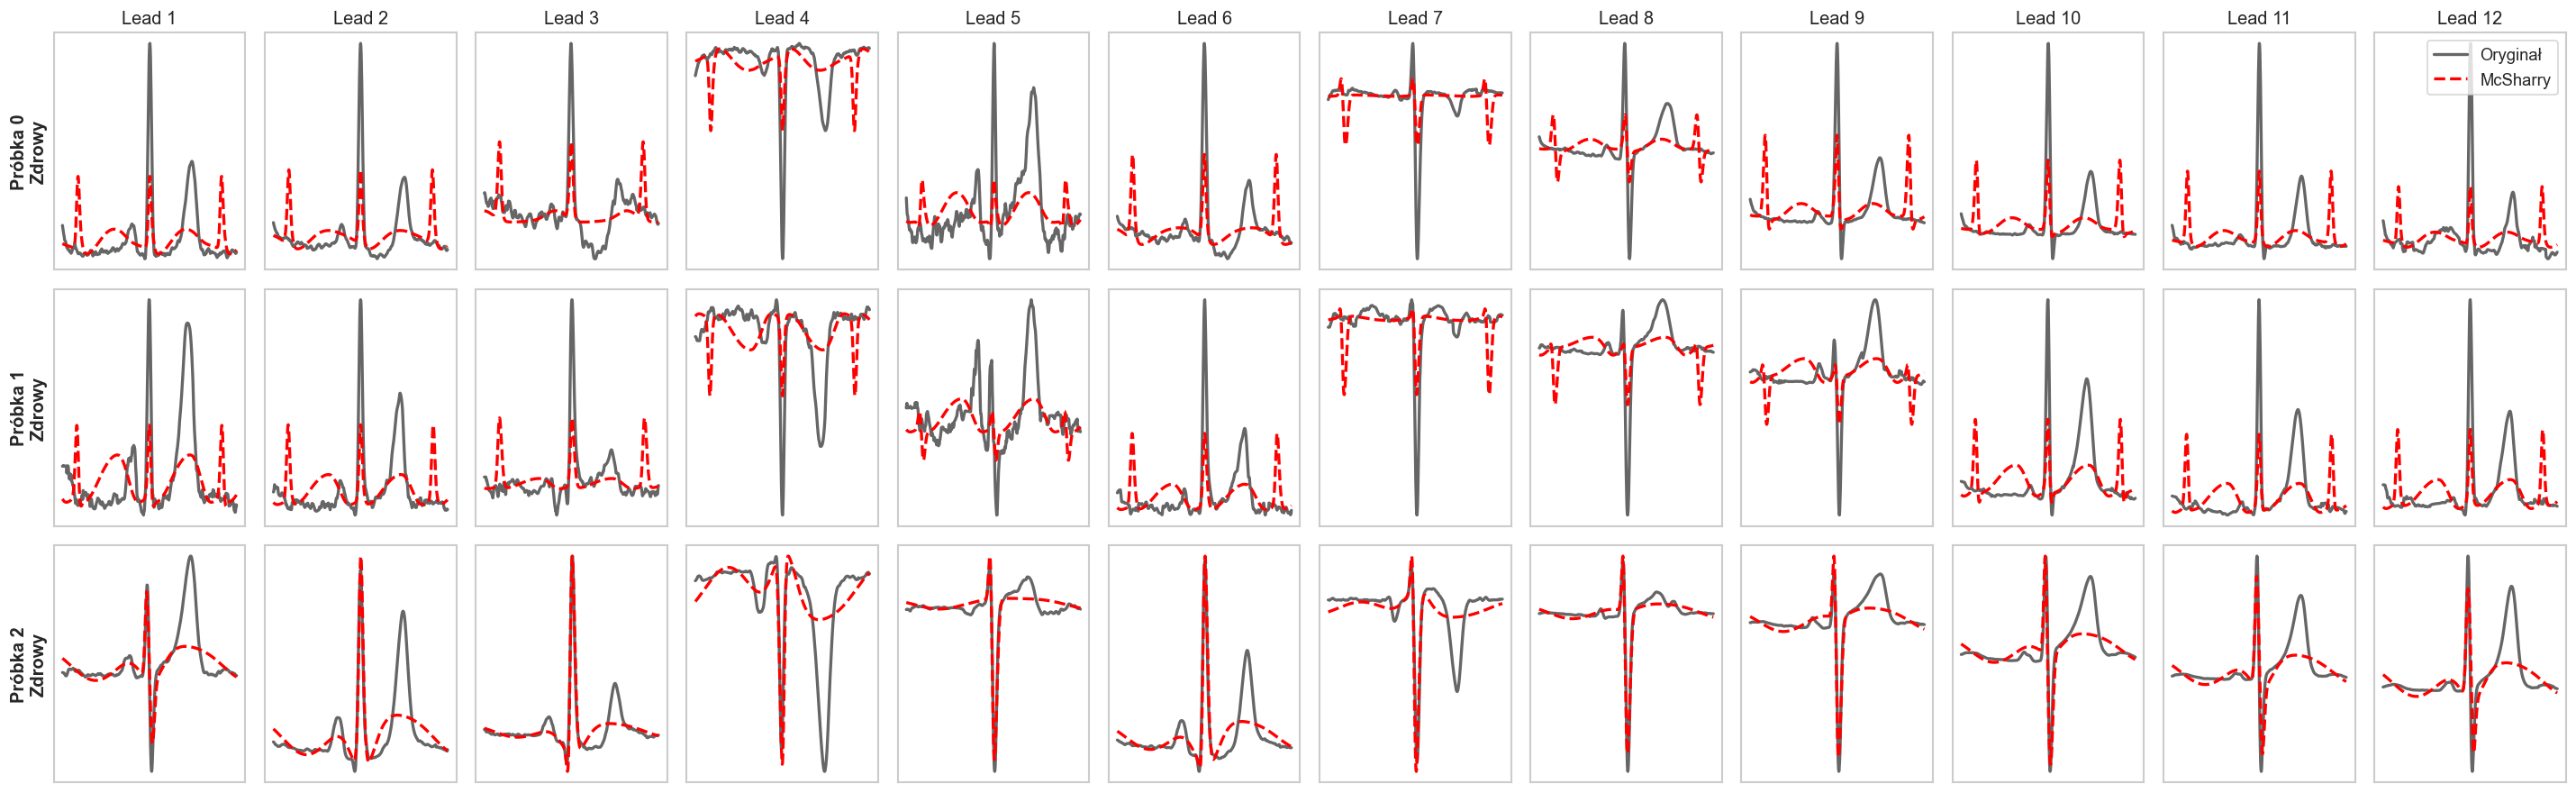

In [10]:
def plot_reconstruction(model, loader, num_samples=3):
    model.eval()
    x, y, median_beats, hr_f = next(iter(loader))
    median_beats = median_beats.to(device)
    hr_f = hr_f.to(device)
    
    with torch.no_grad():
        _, params = model(median_beats, hr_f, return_params=True)
        
    B, C, T_beat = median_beats.shape
    b = params['b']
    theta_i = params['theta']
    a = params['a']
    z0 = params['z0']
    
    t = torch.arange(0, T_beat, device=device).float() * dt
    t = t - (T_beat * dt / 2.0)
    t = t.unsqueeze(0)
    
    theta_t = 2 * math.pi * hr_f.unsqueeze(-1) * t
    z_pred = torch.zeros_like(median_beats)
    
    for i in range(5):
        dtheta = theta_t - theta_i[:, i:i+1]
        dtheta = torch.atan2(torch.sin(dtheta), torch.cos(dtheta))
        gauss = torch.exp(- (dtheta**2) / (2 * b[:, i:i+1]**2))
        z_pred += a[:, :, i:i+1] * gauss.unsqueeze(1)
        
    z_pred += z0.unsqueeze(-1)
    
    median_beats_np = median_beats.cpu().numpy()
    z_pred_np = z_pred.cpu().numpy()
    y_np = y.cpu().numpy()
    
    fig, axes = plt.subplots(num_samples, 12, figsize=(24, 2.5 * num_samples))
    for i in range(num_samples):
        for lead in range(12):
            ax = axes[i, lead]
            ax.plot(median_beats_np[i, lead, :], label='Oryginał', color='black', alpha=0.6, linewidth=2)
            ax.plot(z_pred_np[i, lead, :], label='McSharry', color='red', linestyle='--', linewidth=2)
            if i == 0:
                ax.set_title(f'Lead {lead+1}')
            if lead == 0:
                status = "Chagas+" if y_np[i] == 1 else "Zdrowy"
                ax.set_ylabel(f'Próbka {i}\n{status}', fontsize=12, fontweight='bold')
            ax.set_xticks([])
            ax.set_yticks([])
            if i == 0 and lead == 11:
                ax.legend(loc='upper right')
                
    plt.tight_layout()
    plt.savefig('approach11_reconstruction_sanity_check.png', dpi=300)
    plt.show()

plot_reconstruction(model, val_loader, num_samples=3)

## 6. Feature importance parametrów McSharry'ego

Wyciągam parametry fizyczne dla zbioru walidacyjnego i sprawdzam, które z nich najmocniej korelują z chorobą Chagasa.

Saved best model to approach11_mcsharry_code15_best.pt


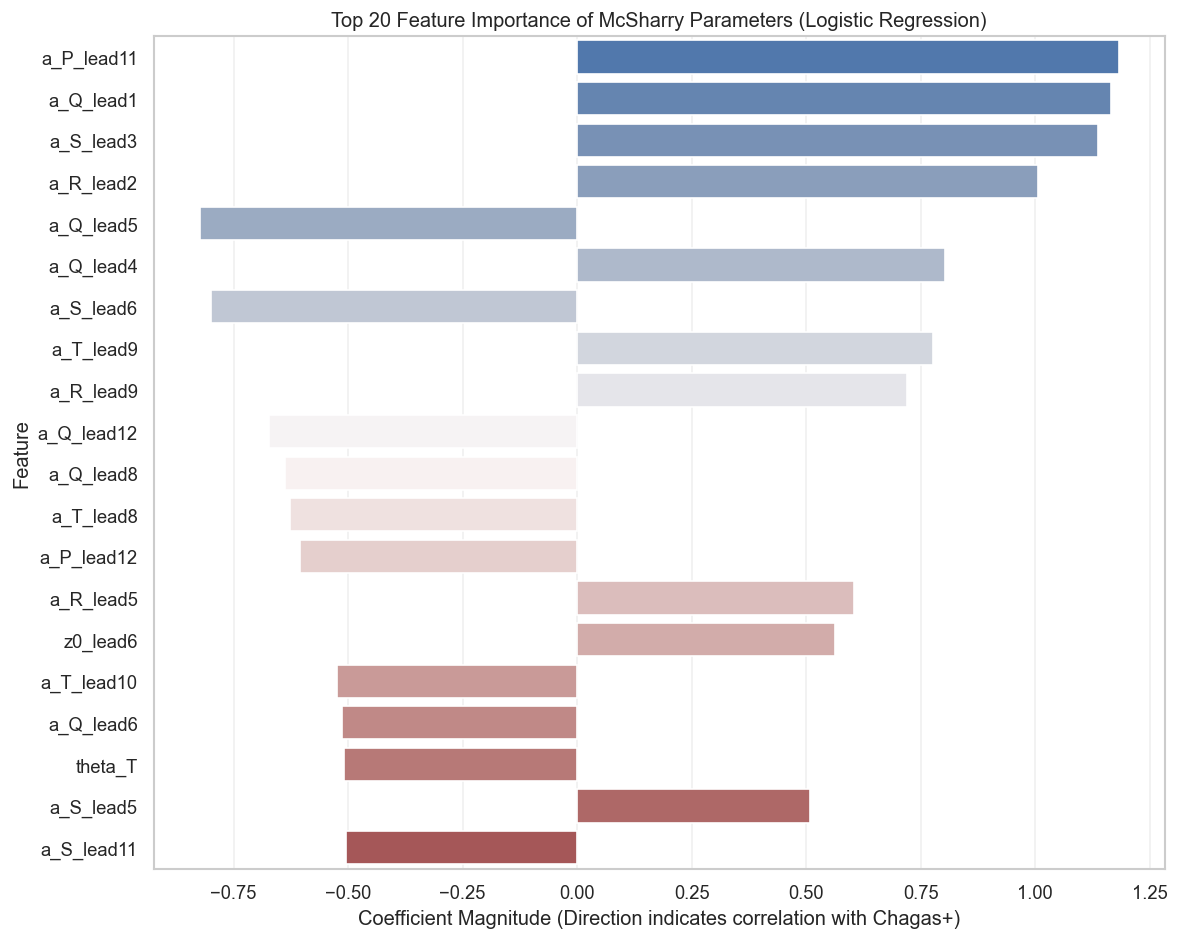

09:53:09 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
09:53:09 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
09:53:09 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
09:53:09 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
09:53:09 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropria

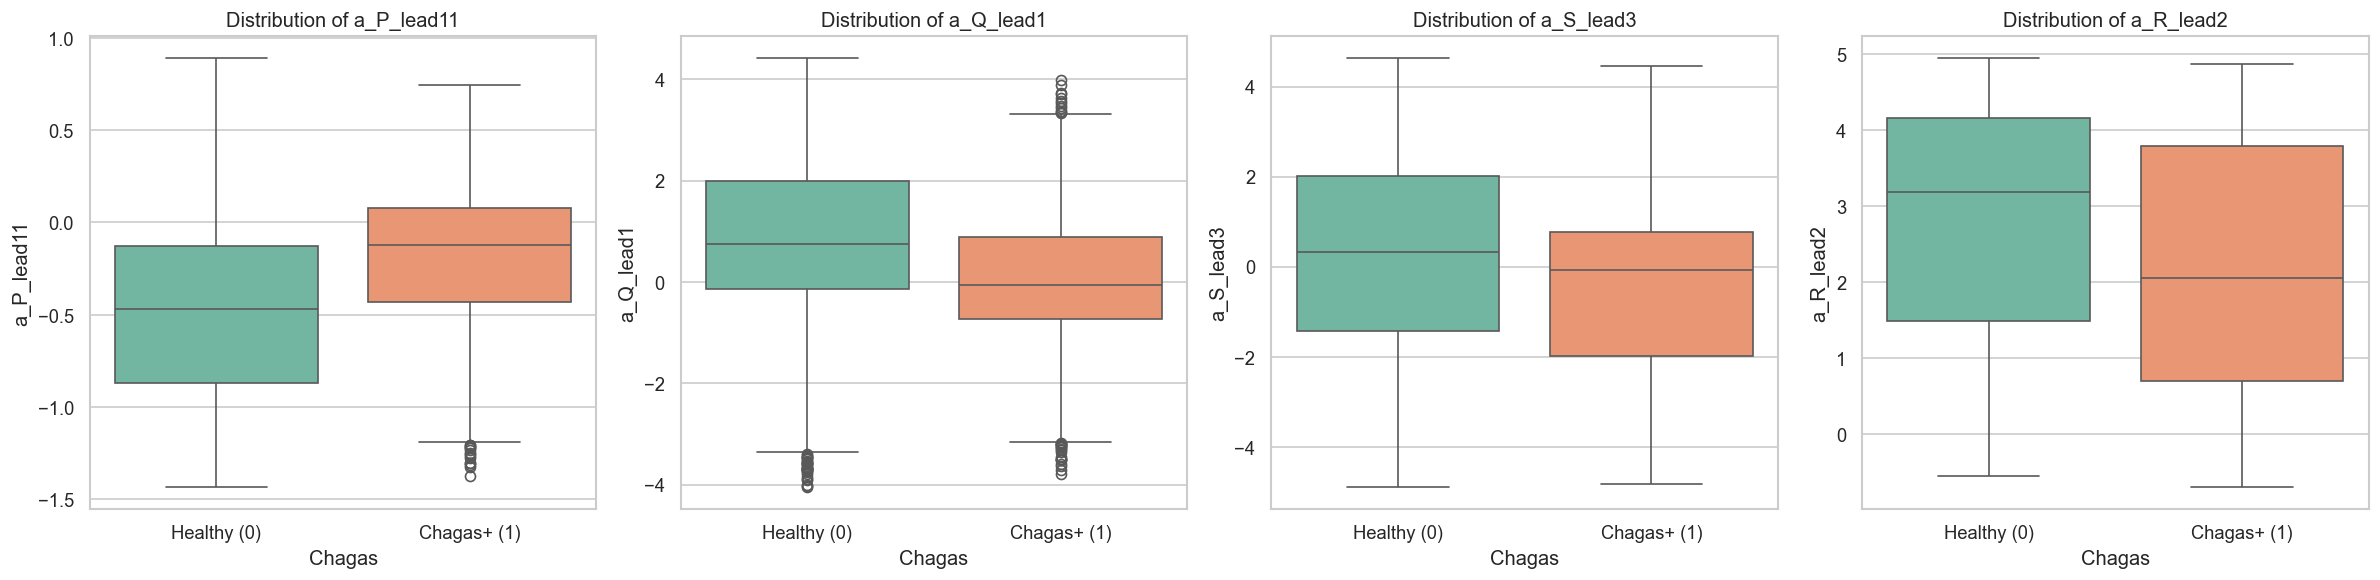

In [11]:
torch.save(model.state_dict(), 'approach11_mcsharry_code15_best.pt')
print('Saved best model to approach11_mcsharry_code15_best.pt')

model.eval()
val_params = []
val_labels = []

with torch.no_grad():
    for x, y, median_beats, hr_f in val_loader:
        median_beats, hr_f = median_beats.to(device), hr_f.to(device)
        _, params = model(median_beats, hr_f, return_params=True)
        
        b = params['b']
        theta = params['theta']
        a = params['a'].view(-1, 60)
        z0 = params['z0']
        
        flat_params = torch.cat([b, theta, a, z0, hr_f.unsqueeze(-1)], dim=-1)
        val_params.append(flat_params.cpu().numpy())
        val_labels.append(y.numpy())

val_params = np.concatenate(val_params, axis=0)
val_labels = np.concatenate(val_labels, axis=0)

param_names = []
for wave in ['P', 'Q', 'R', 'S', 'T']:
    param_names.append(f'b_{wave}')
for wave in ['P', 'Q', 'R', 'S', 'T']:
    param_names.append(f'theta_{wave}')
for lead in range(1, 13):
    for wave in ['P', 'Q', 'R', 'S', 'T']:
        param_names.append(f'a_{wave}_lead{lead}')
for lead in range(1, 13):
    param_names.append(f'z0_lead{lead}')
param_names.append('f (Heart Rate)')

df_params = pd.DataFrame(val_params, columns=param_names)
df_params['Chagas'] = val_labels

scaler = StandardScaler()
X_scaled = scaler.fit_transform(val_params)

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_scaled, val_labels)

importance = clf.coef_[0]
feat_imp = pd.DataFrame({'Feature': param_names, 'Importance': importance})
feat_imp['Abs_Importance'] = feat_imp['Importance'].abs()
feat_imp = feat_imp.sort_values(by='Abs_Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='vlag')
plt.title('Top 20 Feature Importance of McSharry Parameters (Logistic Regression)')
plt.xlabel('Coefficient Magnitude (Direction indicates correlation with Chagas+)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('approach11_feature_importance.png', dpi=300)
plt.show()

top_features = feat_imp['Feature'].head(4).tolist()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, feat in enumerate(top_features):
    sns.boxplot(data=df_params, x='Chagas', y=feat, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribution of {feat}')
    axes[i].set_xticklabels(['Healthy (0)', 'Chagas+ (1)'])

plt.tight_layout()
plt.savefig('approach11_top_features_boxplots.png', dpi=300)
plt.show()

## 7. Domain shift: CODE-15% vs SaMi-Trop

Porównanie rozkładów parametrów McSharry'ego między walidacją (CODE-15%) a SaMi-Trop. Jeśli widać duże przesunięcie (np. inny baseline `z0` czy tętno `f`), tłumaczy to spadek czułości na zbiorze OOD.

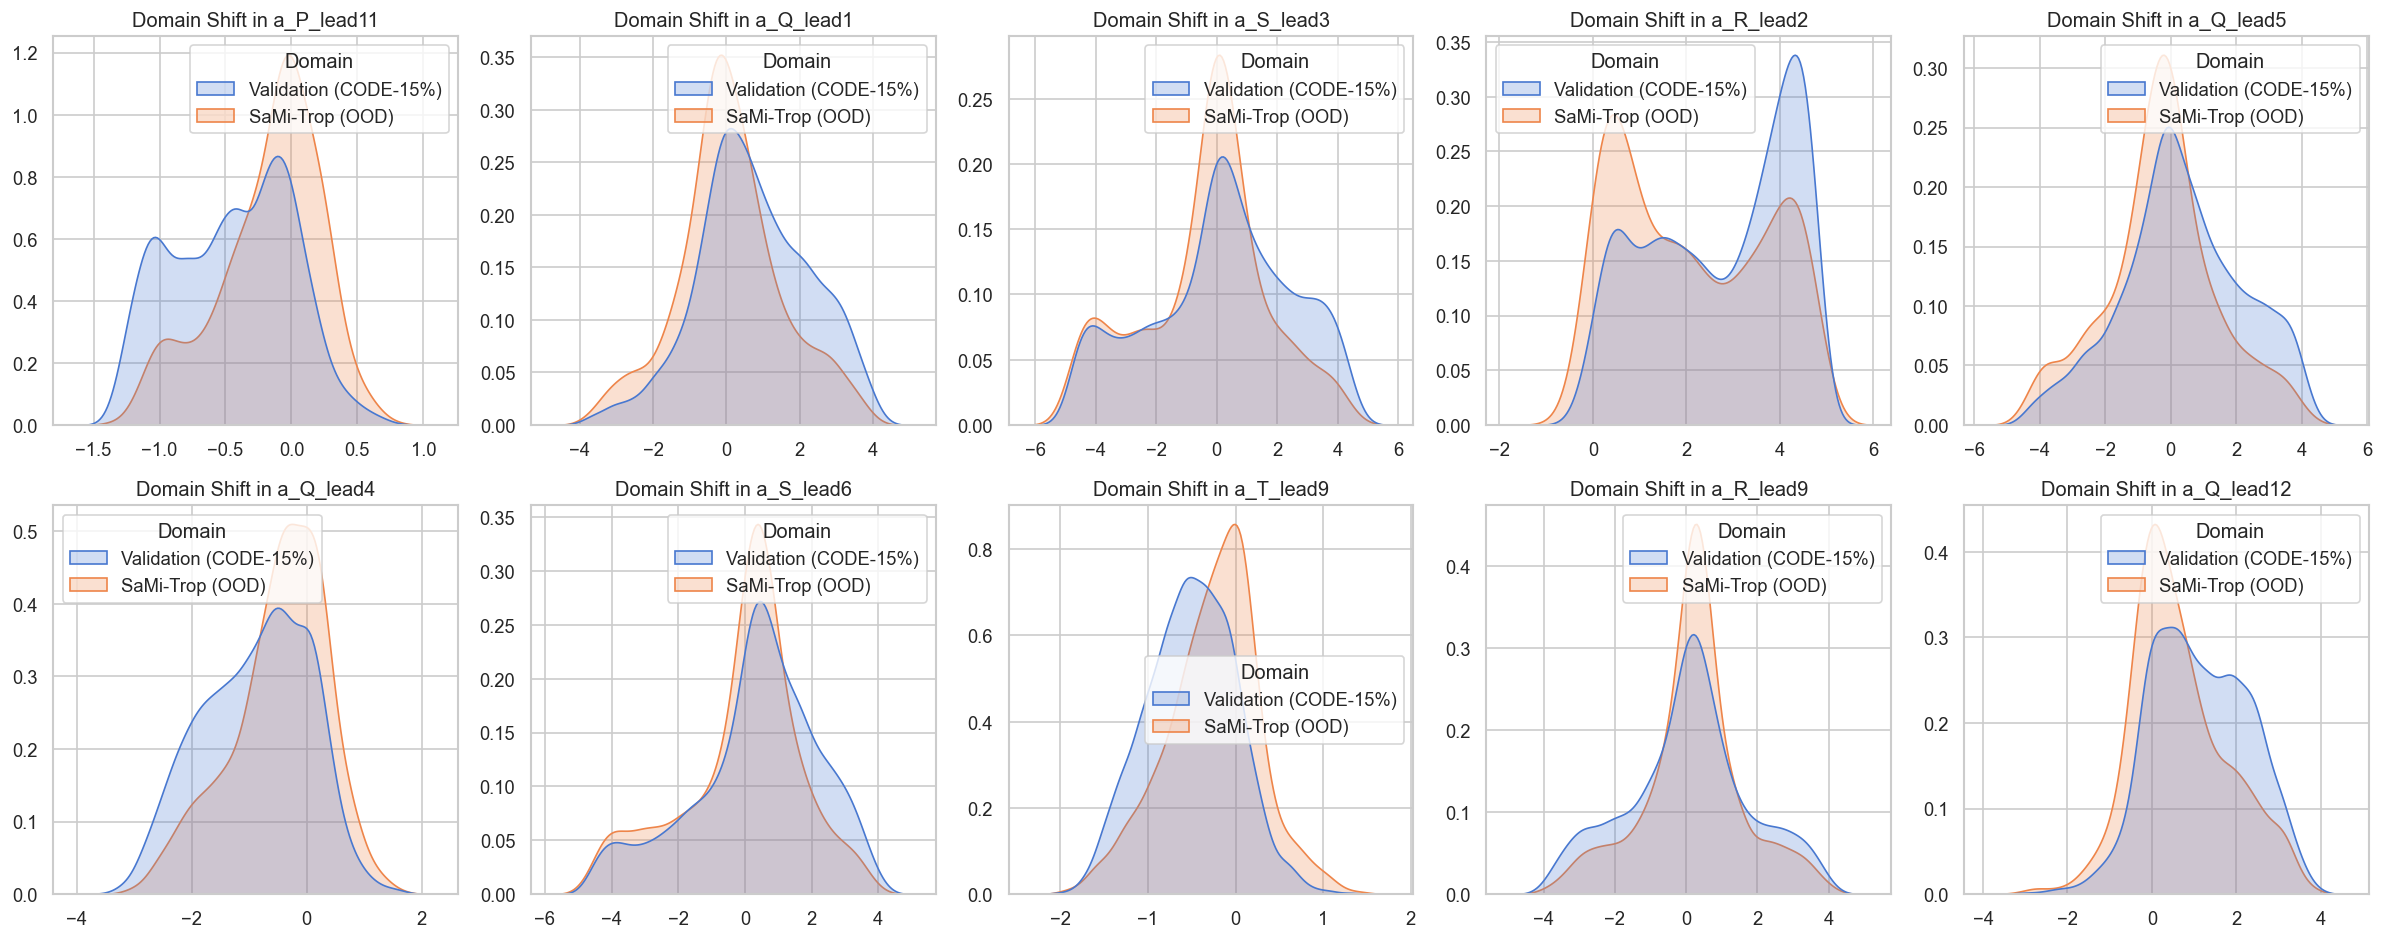

In [12]:
model.eval()
samitrop_params = []

with torch.no_grad():
    for x, y, median_beats, hr_f in samitrop_loader:
        median_beats, hr_f = median_beats.to(device), hr_f.to(device)
        _, params = model(median_beats, hr_f, return_params=True)
        
        b = params['b']
        theta = params['theta']
        a = params['a'].view(-1, 60)
        z0 = params['z0']
        
        flat_params = torch.cat([b, theta, a, z0, hr_f.unsqueeze(-1)], dim=-1)
        samitrop_params.append(flat_params.cpu().numpy())

samitrop_params = np.concatenate(samitrop_params, axis=0)

df_val = pd.DataFrame(val_params, columns=param_names)
df_val['Domain'] = 'Validation (CODE-15%)'

df_samitrop_df = pd.DataFrame(samitrop_params, columns=param_names)
df_samitrop_df['Domain'] = 'SaMi-Trop (OOD)'

df_compare = pd.concat([df_val, df_samitrop_df], axis=0)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

top_10_features = feat_imp['Feature'].head(10).tolist()

for i, param in enumerate(top_10_features):
    sns.kdeplot(data=df_compare, x=param, hue='Domain', fill=True, ax=axes[i], common_norm=False, palette='muted')
    axes[i].set_title(f'Domain Shift in {param}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.savefig('approach11_domain_shift_analysis.png', dpi=300)
plt.show()

---
## 8. Ewaluacja na zbiorze testowym (CODE-15% test set)
Ocena modelu na wydzielonym zbiorze testowym CODE-15%.

In [13]:
model.eval()
ty, tp = [], []
with torch.no_grad():
    for x, y, median_beats, hr_f in test_loader:
        median_beats, hr_f = median_beats.to(device), hr_f.to(device)
        logits = model(median_beats, hr_f)
        ty.append(y.numpy())
        tp.append(torch.sigmoid(logits).cpu().numpy())

ty = np.concatenate(ty)
tp = np.concatenate(tp)
test_m = compute_metrics(ty, tp)

print("="*60)
print("WYNIKI NA ZBIORZE TESTOWYM (CODE-15% held-out)")
print("="*60)
print(f"Liczba probek: {len(ty):,} ({int(ty.sum())} Chagas+ / {int((ty==0).sum())} neg)")
print(f"Prevalencja:   {100*ty.mean():.1f}%")
print("-"*60)
print(f"AUROC:           {test_m.auroc:.4f}")
print(f"AUPRC:           {test_m.auprc:.4f}")
print(f"F1 Score:        {test_m.f1:.4f}")
print(f"Sensitivity:     {test_m.sens:.4f}")
print(f"Specificity:     {test_m.spec:.4f}")
print(f"Challenge Score: {test_m.challenge_score:.4f}")
print("="*60)
print("Porownaj z podejsciami 4-10 (te same dane testowe CODE-15%).")

WYNIKI NA ZBIORZE TESTOWYM (CODE-15% held-out)
Liczba probek: 7,134 (962 Chagas+ / 6172 neg)
Prevalencja:   13.5%
------------------------------------------------------------
AUROC:           0.7710
AUPRC:           0.4004
F1 Score:        0.2285
Sensitivity:     0.1383
Specificity:     0.9888
Challenge Score: 0.2100
Porownaj z podejsciami 4-10 (te same dane testowe CODE-15%).


## 9. Ograniczenia

Klasyfikator dostaje wyłącznie 83 parametry fizyczne. Wektor `ctx` z enkodera jest świadomie odrzucany, co daje pełną interpretowalność kosztem AUROC: suma pięciu gaussów nie złapie fragmentacji QRS ani subtelnych zmian morfologicznych.

Pozycje załamków `theta` i szerokości `b` są wspólne dla wszystkich 12 odprowadzeń. Anatomicznie istnieje lekka asynchronia między odprowadzeniami, ale ujednolicenie stabilizuje trening.

Jeśli rekonstrukcja w sekcji 5 wygląda słabo, FocalLoss prawdopodobnie dominuje nad MSE. Wtedy sensowny jest trening dwuetapowy: najpierw sam autoenkoder przez kilka epok, potem end-to-end.

## 10. OOD evaluation: SaMi-Trop

SaMi-Trop ma tylko próbki Chagas+, więc AUROC jest niezdefiniowany. Używam `samitrop_loader` (osobny od oficjalnego splitu CODE-15%) żeby sprawdzić, jak model przenosi się na inną populację: inny szpital, inny protokół akwizycji, inna demografia.

Skoro wszystkie etykiety są pozytywne, raportuję samą czułość przy kilku progach i porównuję rozkład predykcji z testem CODE-15%. Główny wynik testowy jest w sekcji 8.

SaMi-Trop OOD set: 1631 samples
  Chagas+ rate: 100.0%  (expected: 100%)
CODE-15% test set: 7134 samples
  Chagas+ rate: 13.5%

OOD EVALUATION: SaMi-Trop (all Chagas+)
  Samples:              1,631
  Mean predicted score: 0.3331 (std 0.1280)

  Sensitivity at various decision thresholds:
    thr=0.1: 0.9945  (1622/1631 detected)
    thr=0.2: 0.8596  (1402/1631 detected)
    thr=0.3: 0.5340  (871/1631 detected)
    thr=0.5: 0.1312  (214/1631 detected)


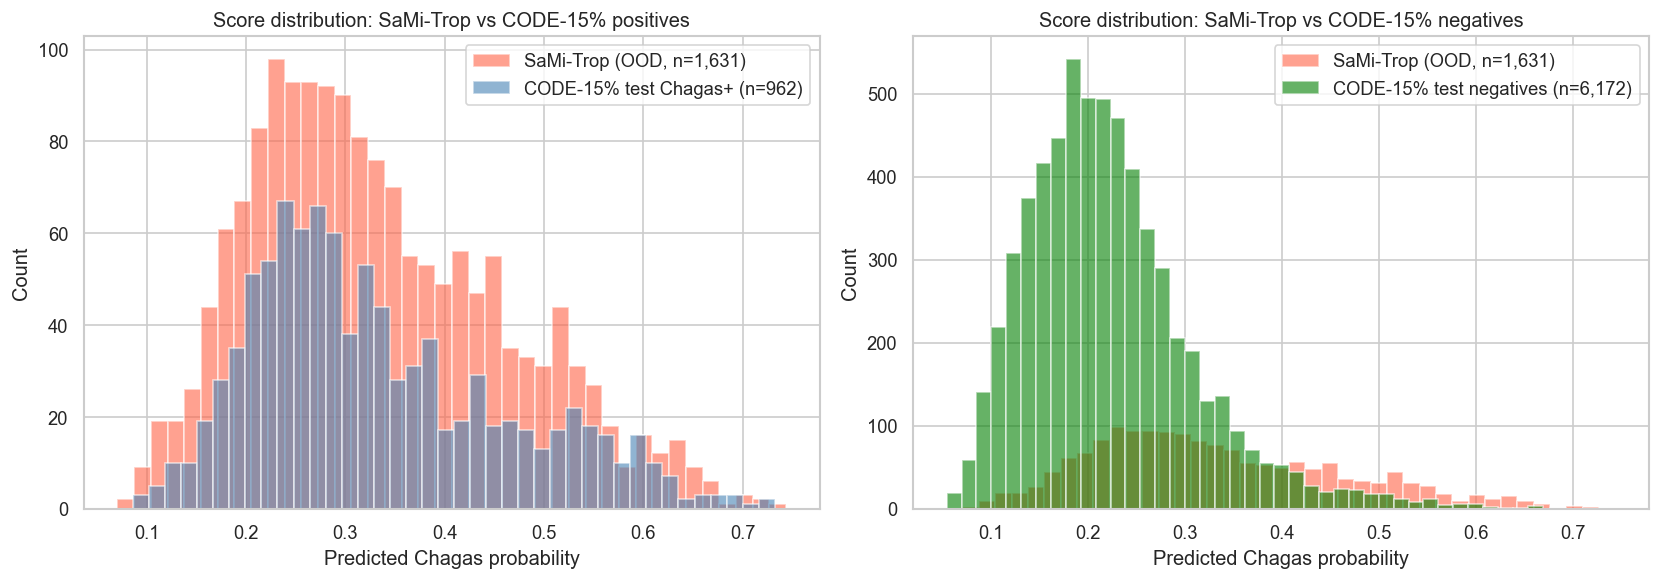


Note: Low scores on SaMi-Trop indicate domain shift (different acquisition
protocol, patient demographics). This is expected and does NOT invalidate
the CODE-15% test results in Section 8.


In [14]:

labels = all_labels

print(f"SaMi-Trop OOD set: {len(samitrop_indices)} samples")
print(f"  Chagas+ rate: {100 * labels[samitrop_indices].mean():.1f}%  (expected: 100%)")
print(f"CODE-15% test set: {len(test_indices)} samples")
print(f"  Chagas+ rate: {100 * labels[test_indices].mean():.1f}%")

model.eval()
samitrop_y, samitrop_p = [], []
with torch.no_grad():
    for x, y, median_beats, hr_f in samitrop_loader:
        median_beats, hr_f = median_beats.to(device), hr_f.to(device)
        logits = model(median_beats, hr_f)
        samitrop_y.append(y.numpy())
        samitrop_p.append(torch.sigmoid(logits).cpu().numpy())

samitrop_y = np.concatenate(samitrop_y)
samitrop_p = np.concatenate(samitrop_p)

thresholds = [0.1, 0.2, 0.3, 0.5]
print()
print("=" * 60)
print("OOD EVALUATION: SaMi-Trop (all Chagas+)")
print("=" * 60)
print(f"  Samples:              {len(samitrop_y):,}")
print(f"  Mean predicted score: {samitrop_p.mean():.4f} (std {samitrop_p.std():.4f})")
print()
print("  Sensitivity at various decision thresholds:")
for thr in thresholds:
    sens = (samitrop_p >= thr).mean()
    print(f"    thr={thr:.1f}: {sens:.4f}  ({int(sens*len(samitrop_y))}/{len(samitrop_y)} detected)")
print("=" * 60)

code15_test_p = []
code15_test_y = []
with torch.no_grad():
    for x, y, median_beats, hr_f in test_loader:
        median_beats, hr_f = median_beats.to(device), hr_f.to(device)
        logits = model(median_beats, hr_f)
        code15_test_y.append(y.numpy())
        code15_test_p.append(torch.sigmoid(logits).cpu().numpy())

code15_test_y = np.concatenate(code15_test_y)
code15_test_p = np.concatenate(code15_test_p)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(samitrop_p, bins=40, alpha=0.6, color="tomato", label=f"SaMi-Trop (OOD, n={len(samitrop_p):,})")
ax.hist(code15_test_p[code15_test_y == 1], bins=40, alpha=0.6, color="steelblue", label=f"CODE-15% test Chagas+ (n={int(code15_test_y.sum()):,})")
ax.set_xlabel("Predicted Chagas probability")
ax.set_ylabel("Count")
ax.set_title("Score distribution: SaMi-Trop vs CODE-15% positives")
ax.legend()

ax = axes[1]
ax.hist(samitrop_p, bins=40, alpha=0.6, color="tomato", label=f"SaMi-Trop (OOD, n={len(samitrop_p):,})")
ax.hist(code15_test_p[code15_test_y == 0], bins=40, alpha=0.6, color="green", label=f"CODE-15% test negatives (n={int((code15_test_y==0).sum()):,})")
ax.set_xlabel("Predicted Chagas probability")
ax.set_ylabel("Count")
ax.set_title("Score distribution: SaMi-Trop vs CODE-15% negatives")
ax.legend()

plt.tight_layout()
plt.savefig("approach11_ood_samitrop_score_dist.png", dpi=300)
plt.show()
